# 06 — Claude API Classifiers

**Why this model?** Unlike the trained models (TF-IDF, sentence transformer, DistilBERT), Claude can *reason* about category definitions. It can understand that "Commons Education Committee report on Ofsted" is about political environment (a parliamentary body making policy) rather than just matching keywords. This should help with the overlapping `political_environment` ↔ `policy_practice_research` ↔ `what_matters_ed` triangle.

**Two approaches:**
- **Zero-shot** — describe the 6 categories, ask Claude to classify. No training examples.
- **Few-shot** — same prompt but with example articles for each category to disambiguate boundaries.

**Steps:**
1. Define category descriptions and prompt template
2. Zero-shot classification on val set
3. Few-shot classification on val set
4. Evaluate both: macro F1, top-2 accuracy, per-class breakdown
5. Compare to all previous models

**Input:** `data/modelling/val.csv`

**Benchmarks to beat:** TF-IDF 0.675, Sentence Transformer 0.765, DistilBERT 0.750

# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

from anthropic import Anthropic
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
DATA_DIR = Path("../data/modelling")

client = Anthropic()  # uses ANTHROPIC_API_KEY env variable

MODEL = "claude-sonnet-4-20250514"  # fast and cheap for classification

# 1. Load data

In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")

label_names = sorted(val_df["target"].unique())

print(f"Val: {val_df.shape[0]} rows")
print(f"Categories: {label_names}")

Val: 167 rows
Categories: ['edtech', 'four_nations', 'policy_practice_research', 'political_environment_key_organisations', 'teacher_rrd', 'what_matters_ed']


# 2. Define category descriptions

Clear descriptions help Claude understand the boundaries between categories — especially the overlapping triangle.

In [7]:
#Category descriptions were written based on findings from the previous notebooks: 
#TF-IDF top features (what vocabulary defines each class), 
#missed predictions and false positives (where categories overlap), and curator input. 
#The key distinction is between the overlapping triangle: `policy_practice_research` emphasises the research itself, `political_environment` emphasises the organisation's action, and `what_matters_ed` emphasises the topic. 
#These descriptions may need refining after seeing results — or checking with the curators.


CATEGORY_DESCRIPTIONS = {
    "edtech": "Articles about educational technology, AI in education, digital tools for learning, online learning platforms, and technology policy in schools.",
    "four_nations": "Articles specifically about education in Scotland, Wales, Northern Ireland, or devolved education policy. Must have a clear geographic focus on one of the four nations.",
    "policy_practice_research": "Research reports, academic studies, evidence reviews, and practice-focused publications about education. The emphasis is on the research or evidence itself, not on the organisation publishing it.",
    "political_environment_key_organisations": "News and announcements from key political and policy organisations (DfE, Ofsted, parliamentary committees, think tanks). The emphasis is on the organisation's action or announcement, not on the topic.",
    "teacher_rrd": "Articles specifically about teacher recruitment, retention, development, training, pay, workload, or the teaching profession. Must be primarily about teachers as a workforce.",
    "what_matters_ed": "Articles about broader education issues that matter to children and families: SEND, attendance, mental health, disadvantage, pupil welfare, school meals, poverty.",
}

for cat, desc in CATEGORY_DESCRIPTIONS.items():
    print(f"{cat}:\n  {desc}\n")

edtech:
  Articles about educational technology, AI in education, digital tools for learning, online learning platforms, and technology policy in schools.

four_nations:
  Articles specifically about education in Scotland, Wales, Northern Ireland, or devolved education policy. Must have a clear geographic focus on one of the four nations.

policy_practice_research:
  Research reports, academic studies, evidence reviews, and practice-focused publications about education. The emphasis is on the research or evidence itself, not on the organisation publishing it.

political_environment_key_organisations:
  News and announcements from key political and policy organisations (DfE, Ofsted, parliamentary committees, think tanks). The emphasis is on the organisation's action or announcement, not on the topic.

teacher_rrd:
  Articles specifically about teacher recruitment, retention, development, training, pay, workload, or the teaching profession. Must be primarily about teachers as a workforce

# 3. Zero-shot classification

In [5]:
SYSTEM_PROMPT = """You are a classifier for an education policy newsletter. 
Classify each article into exactly one of these categories:

{categories}

Respond with ONLY a JSON object in this format:
{{
  "category": "the_category_name",
  "confidence": 0.0 to 1.0,
  "second_category": "the_second_most_likely_category",
  "second_confidence": 0.0 to 1.0
}}

Do not include any other text."""

def format_system_prompt(category_descriptions, examples=None):
    categories = "\n".join(
        f"- {name}: {desc}" for name, desc in category_descriptions.items()
    )
    prompt = SYSTEM_PROMPT.format(categories=categories)
    if examples:
        prompt += "\n\nHere are example articles for each category:\n" + examples
    return prompt

print(format_system_prompt(CATEGORY_DESCRIPTIONS)[:500] + "...")

You are a classifier for an education policy newsletter. 
Classify each article into exactly one of these categories:

- edtech: Articles about educational technology, AI in education, digital tools for learning, online learning platforms, and technology policy in schools.
- four_nations: Articles specifically about education in Scotland, Wales, Northern Ireland, or devolved education policy. Must have a clear geographic focus on one of the four nations.
- policy_practice_research: Research repo...


In [6]:
def classify_article(text, system_prompt, model=MODEL):
    """Classify a single article using Claude API."""
    response = client.messages.create(
        model=model,
        max_tokens=150,
        system=system_prompt,
        messages=[{"role": "user", "content": f"Classify this article:\n\n{text}"}],
    )
    try:
        result = json.loads(response.content[0].text)
        return result
    except json.JSONDecodeError:
        return {"category": "parse_error", "confidence": 0.0, "second_category": "parse_error", "second_confidence": 0.0}

In [10]:
# Test on a single article first
test_text = val_df.iloc[0]["text_clean"]
test_true = val_df.iloc[0]["target"]

system_prompt_zero = format_system_prompt(CATEGORY_DESCRIPTIONS)
result = classify_article(test_text, system_prompt_zero)

print(f"True: {test_true}")
print(f"Predicted: {result}")
print(f"Text: {test_text[:200]}")

True: political_environment_key_organisations
Predicted: {'category': 'political_environment_key_organisations', 'confidence': 0.85, 'second_category': 'policy_practice_research', 'second_confidence': 0.15}
Text: LGIU - Sticking with the mission: no time for the UK government to lose momentum The UK Labour government put mission-driven government at the heart of their election manifesto and since taking office


In [9]:
# Run zero-shot on full val set
# This will take a few minutes due to API rate limits
zero_shot_results = []

for i, row in val_df.iterrows():
    result = classify_article(row["text_clean"], system_prompt_zero)
    result["true_label"] = row["target"]
    result["text"] = row["text_clean"][:100]
    zero_shot_results.append(result)

    if (len(zero_shot_results)) % 20 == 0:
        print(f"Processed {len(zero_shot_results)}/{len(val_df)} articles...")
    
    time.sleep(0.5)  # rate limit buffer

print(f"\nDone. {len(zero_shot_results)} articles classified.")

# Convert to DataFrame
zero_df = pd.DataFrame(zero_shot_results)

Processed 20/167 articles...
Processed 40/167 articles...
Processed 60/167 articles...
Processed 80/167 articles...
Processed 100/167 articles...
Processed 120/167 articles...
Processed 140/167 articles...
Processed 160/167 articles...

Done. 167 articles classified.


In [11]:
# Check for parse errors or unexpected categories
print("Predicted categories:")
print(zero_df["category"].value_counts())

# Fix any category names that don't match
invalid = zero_df[~zero_df["category"].isin(label_names)]
if len(invalid) > 0:
    print(f"\n{len(invalid)} invalid predictions:")
    print(invalid[["category", "true_label", "text"]].to_string())

Predicted categories:
category
policy_practice_research                   43
teacher_rrd                                31
political_environment_key_organisations    28
what_matters_ed                            25
four_nations                               20
edtech                                     19
parse_error                                 1
Name: count, dtype: int64

1 invalid predictions:
       category       true_label                                                                                                  text
46  parse_error  what_matters_ed  See also Schoolsweek coverage of the same report under the heading Poorer secondary pupils now 19 mo


## 3b. Zero-shot evaluation

In [12]:
# Filter to valid predictions only
valid_zero = zero_df[zero_df["category"].isin(label_names)].copy()

y_true_zero = valid_zero["true_label"]
y_pred_zero = valid_zero["category"]

f1_zero = f1_score(y_true_zero, y_pred_zero, average="macro")
print(f"Zero-shot Macro F1: {f1_zero:.3f} ({len(valid_zero)}/{len(val_df)} valid predictions)\n")
print(classification_report(y_true_zero, y_pred_zero))

Zero-shot Macro F1: 0.683 (166/167 valid predictions)

                                         precision    recall  f1-score   support

                                 edtech       0.95      0.69      0.80        26
                           four_nations       0.95      0.86      0.90        22
               policy_practice_research       0.42      0.75      0.54        24
political_environment_key_organisations       0.61      0.47      0.53        36
                            teacher_rrd       0.74      0.79      0.77        29
                        what_matters_ed       0.60      0.52      0.56        29

                               accuracy                           0.66       166
                              macro avg       0.71      0.68      0.68       166
                           weighted avg       0.70      0.66      0.67       166



In [14]:
# Top-2 accuracy using Claude's second_category
valid_zero["in_top2"] = (
    (valid_zero["category"] == valid_zero["true_label"]) |
    (valid_zero["second_category"] == valid_zero["true_label"])
)
top2_zero = valid_zero["in_top2"].mean()

print(f"Top-1 accuracy: {(y_pred_zero == y_true_zero).mean():.3f}")
print(f"Top-2 accuracy: {top2_zero:.3f}")

# Per-class top-2
print("\nPer-class top-2 accuracy:\n")
for cls in label_names:
    mask = valid_zero["true_label"] == cls
    hit_rate = valid_zero.loc[mask, "in_top2"].mean()
    print(f"  {cls:45s} {hit_rate:.0%}  ({mask.sum()} samples)")

Top-1 accuracy: 0.663
Top-2 accuracy: 0.928

Per-class top-2 accuracy:

  edtech                                        96%  (26 samples)
  four_nations                                  100%  (22 samples)
  policy_practice_research                      96%  (24 samples)
  political_environment_key_organisations       86%  (36 samples)
  teacher_rrd                                   93%  (29 samples)
  what_matters_ed                               90%  (29 samples)


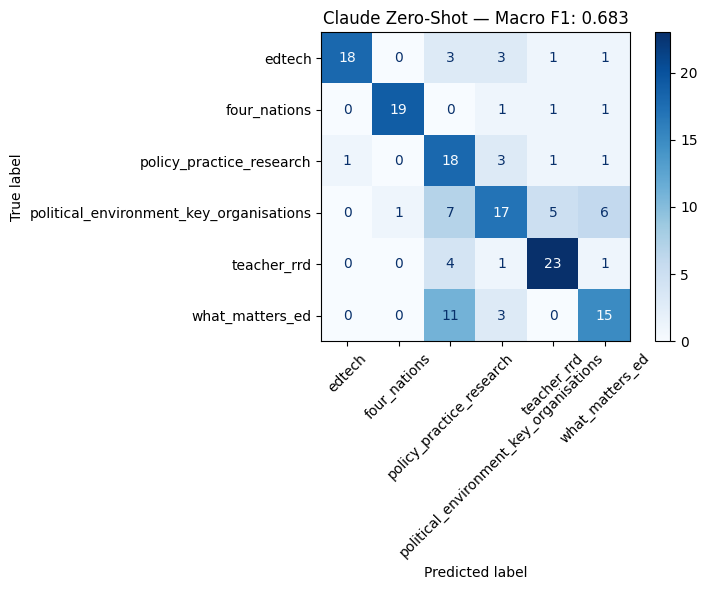

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true_zero, y_pred_zero, ax=ax, xticks_rotation=45, cmap="Blues"
)
ax.set_title(f"Claude Zero-Shot — Macro F1: {f1_zero:.3f}")
plt.tight_layout()
plt.show()

In [16]:
# Missed predictions
print("--- MISSED: true label not in top 2 ---\n")
missed = valid_zero[~valid_zero["in_top2"]]
for _, row in missed.iterrows():
    print(f"True: {row['true_label']}")
    print(f"  1. {row['category']} ({row['confidence']:.2f})  2. {row['second_category']} ({row['second_confidence']:.2f})")
    print(f"  Text: {row['text']}")
    print()

--- MISSED: true label not in top 2 ---

True: teacher_rrd
  1. policy_practice_research (0.85)  2. political_environment_key_organisations (0.15)
  Text: This is the first in a series of three webinars, building on the data from EPI's effective school gr

True: policy_practice_research
  1. edtech (0.85)  2. political_environment_key_organisations (0.15)
  Text: NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is lik

True: edtech
  1. what_matters_ed (0.80)  2. political_environment_key_organisations (0.60)
  Text: The Guardian - More than 90% of schools in England ban mobile phone use, survey shows Head of Nation

True: political_environment_key_organisations
  1. what_matters_ed (0.85)  2. policy_practice_research (0.15)
  Text: Centre for Young Lives, Play Commission report – Everything to Play For: A Plan to Ensure Every Chil

True: political_environment_key_organisations
  1. policy_practice_research (0.85)  2. teacher_rrd (0.15)
  Te

In [44]:
# False positives for zero-shot
for cls in label_names:
    fps = valid_zero[(valid_zero["category"] == cls) & (valid_zero["true_label"] != cls)]
    if len(fps) > 0:
        print(f"\n--- False positives for {cls} ({len(fps)}) ---\n")
        for _, row in fps.iterrows():
            print(f"  Predicted: {cls} ({row['confidence']:.2f})")
            print(f"  Actual:    {row['true_label']}")
            print(f"  Text:      {row['text']}")
            print()


--- False positives for edtech (1) ---

  Predicted: edtech (0.85)
  Actual:    policy_practice_research
  Text:      NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is lik


--- False positives for four_nations (1) ---

  Predicted: four_nations (0.95)
  Actual:    political_environment_key_organisations
  Text:      The Scottish government has announced its 2023-24 Programme for Government, This will see the creati


--- False positives for policy_practice_research (25) ---

  Predicted: policy_practice_research (0.85)
  Actual:    what_matters_ed
  Text:      The Conversation - Home education: why are so many parents choosing it over mainstream school? Lucie

  Predicted: policy_practice_research (0.80)
  Actual:    what_matters_ed
  Text:      Sutton Trust research brief - Double Disadvantage? Socio-economic inequalities in the SEND system Ch

  Predicted: policy_practice_research (0.85)
  Actual:    teacher_rrd
  Text:      This is th

### Interpretation: Zero-shot

**Macro F1: 0.683** — nearly matches TF-IDF baseline (0.675) with no training data. **Top-2: 92.8% — best of all models** because Claude sees both plausible interpretations of ambiguous articles.

Main bias: over-predicts `policy_practice_research` (43 vs 24 actual) — Claude classifies by document type ("this is a report"), curator classifies by newsletter relevance ("this is about SEND"). Opposite bias to trained models. False positive analysis confirms this: 25 false positives for `policy_practice_research` alone, more than all other categories combined. 12 missed, all in the triangle.

Few-shot examples should fix this by showing Claude how the curator actually uses the categories, not just what they mean.


# 4. Few-shot classification

Add example articles for each category to help Claude understand the boundaries — especially the overlapping triangle.

In [17]:
# Select 2 clear examples per category from training data
np.random.seed(42)
examples_text = ""

for cat in label_names:
    cat_df = train_df[train_df["target"] == cat]
    samples = cat_df.sample(2, random_state=42)
    examples_text += f"\n{cat}:\n"
    for _, row in samples.iterrows():
        examples_text += f"  - {row['text_clean'][:200]}\n"

print(examples_text[:1000] + "...")


edtech:
  - Society for Research into Higher Education (SRHE) - Inclusive AI Roundtable Webinar Series This roundtable series is an opportunity to explore experiences and emerging research specifically in relatio
  - UK Parliament Culture Media & Sports Committee Call for evidence - Children's tv and video content Deadline: 4 September. This inquiry will explore issues relating to parental control of online conten

four_nations:
  - Scottish Government - Ending the Universal Credit two-child cap The Scottish Government is launching a consultation on its plans to end the two-child cap on benefits.
  - BBC Northern Ireland - Budget cuts could lead to shorter school days, warn principals Northern Ireland head teachers warn that stripped back budgets will potential lead to shorter school days and fewe

policy_practice_research:
  - BERA blog - Unlocking civic potential: Insights from the launch event of OECD's report on higher education and regional development Femi Owolade, Sheffield Hal

In [18]:
# Run few-shot on full val set
system_prompt_few = format_system_prompt(CATEGORY_DESCRIPTIONS, examples=examples_text)

few_shot_results = []

for i, row in val_df.iterrows():
    result = classify_article(row["text_clean"], system_prompt_few)
    result["true_label"] = row["target"]
    result["text"] = row["text_clean"][:100]
    few_shot_results.append(result)

    if (len(few_shot_results)) % 20 == 0:
        print(f"Processed {len(few_shot_results)}/{len(val_df)} articles...")
    
    time.sleep(0.5)  # rate limit buffer

print(f"\nDone. {len(few_shot_results)} articles classified.")

few_df = pd.DataFrame(few_shot_results)

Processed 20/167 articles...
Processed 40/167 articles...
Processed 60/167 articles...
Processed 80/167 articles...
Processed 100/167 articles...
Processed 120/167 articles...
Processed 140/167 articles...
Processed 160/167 articles...

Done. 167 articles classified.


In [19]:
# Check for parse errors
print("Predicted categories:")
print(few_df["category"].value_counts())

invalid_few = few_df[~few_df["category"].isin(label_names)]
if len(invalid_few) > 0:
    print(f"\n{len(invalid_few)} invalid predictions:")
    print(invalid_few[["category", "true_label", "text"]].to_string())

Predicted categories:
category
political_environment_key_organisations    35
policy_practice_research                   35
what_matters_ed                            31
teacher_rrd                                29
four_nations                               19
edtech                                     18
Name: count, dtype: int64


## 4b. Few-shot evaluation

In [20]:
valid_few = few_df[few_df["category"].isin(label_names)].copy()

y_true_few = valid_few["true_label"]
y_pred_few = valid_few["category"]

f1_few = f1_score(y_true_few, y_pred_few, average="macro")
print(f"Few-shot Macro F1: {f1_few:.3f} ({len(valid_few)}/{len(val_df)} valid predictions)\n")
print(classification_report(y_true_few, y_pred_few))

Few-shot Macro F1: 0.717 (167/167 valid predictions)

                                         precision    recall  f1-score   support

                                 edtech       0.94      0.65      0.77        26
                           four_nations       0.95      0.82      0.88        22
               policy_practice_research       0.49      0.71      0.58        24
political_environment_key_organisations       0.60      0.58      0.59        36
                            teacher_rrd       0.79      0.79      0.79        29
                        what_matters_ed       0.68      0.70      0.69        30

                               accuracy                           0.70       167
                              macro avg       0.74      0.71      0.72       167
                           weighted avg       0.73      0.70      0.71       167



In [21]:
# Top-2 accuracy
valid_few["in_top2"] = (
    (valid_few["category"] == valid_few["true_label"]) |
    (valid_few["second_category"] == valid_few["true_label"])
)
top2_few = valid_few["in_top2"].mean()

print(f"Top-1 accuracy: {(y_pred_few == y_true_few).mean():.3f}")
print(f"Top-2 accuracy: {top2_few:.3f}")

# Per-class top-2
print("\nPer-class top-2 accuracy:\n")
for cls in label_names:
    mask = valid_few["true_label"] == cls
    hit_rate = valid_few.loc[mask, "in_top2"].mean()
    print(f"  {cls:45s} {hit_rate:.0%}  ({mask.sum()} samples)")

Top-1 accuracy: 0.701
Top-2 accuracy: 0.934

Per-class top-2 accuracy:

  edtech                                        96%  (26 samples)
  four_nations                                  100%  (22 samples)
  policy_practice_research                      92%  (24 samples)
  political_environment_key_organisations       89%  (36 samples)
  teacher_rrd                                   93%  (29 samples)
  what_matters_ed                               93%  (30 samples)


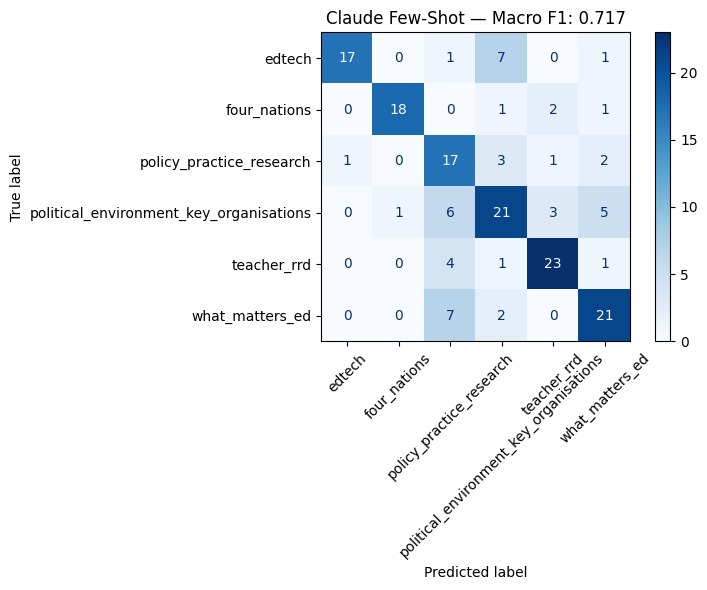

In [22]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true_few, y_pred_few, ax=ax, xticks_rotation=45, cmap="Blues"
)
ax.set_title(f"Claude Few-Shot — Macro F1: {f1_few:.3f}")
plt.tight_layout()
plt.show()

In [23]:
# Missed predictions
print("--- MISSED: true label not in top 2 ---\n")
missed_few = valid_few[~valid_few["in_top2"]]
for _, row in missed_few.iterrows():
    print(f"True: {row['true_label']}")
    print(f"  1. {row['category']} ({row['confidence']:.2f})  2. {row['second_category']} ({row['second_confidence']:.2f})")
    print(f"  Text: {row['text']}")
    print()

--- MISSED: true label not in top 2 ---

True: policy_practice_research
  1. political_environment_key_organisations (0.80)  2. what_matters_ed (0.60)
  Text: Education Endowment Foundation - New local partnerships launched to help disadvantaged pupils Up to 

True: teacher_rrd
  1. policy_practice_research (0.80)  2. political_environment_key_organisations (0.20)
  Text: This is the first in a series of three webinars, building on the data from EPI's effective school gr

True: policy_practice_research
  1. edtech (0.90)  2. political_environment_key_organisations (0.70)
  Text: NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is lik

True: edtech
  1. what_matters_ed (0.80)  2. political_environment_key_organisations (0.20)
  Text: The Guardian - More than 90% of schools in England ban mobile phone use, survey shows Head of Nation

True: political_environment_key_organisations
  1. what_matters_ed (0.90)  2. policy_practice_research (0.70)


In [25]:
# False positives for few-shot
for cls in label_names:
    fps = valid_few[(valid_few["category"] == cls) & (valid_few["true_label"] != cls)]
    if len(fps) > 0:
        print(f"\n--- False positives for {cls} ({len(fps)}) ---\n")
        for _, row in fps.iterrows():
            print(f"  Predicted: {cls} ({row['confidence']:.2f})")
            print(f"  Actual:    {row['true_label']}")
            print(f"  Text:      {row['text']}")
            print()


--- False positives for edtech (1) ---

  Predicted: edtech (0.90)
  Actual:    policy_practice_research
  Text:      NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is lik


--- False positives for four_nations (1) ---

  Predicted: four_nations (0.95)
  Actual:    political_environment_key_organisations
  Text:      The Scottish government has announced its 2023-24 Programme for Government, This will see the creati


--- False positives for policy_practice_research (18) ---

  Predicted: policy_practice_research (0.80)
  Actual:    what_matters_ed
  Text:      Sutton Trust research brief - Double Disadvantage? Socio-economic inequalities in the SEND system Ch

  Predicted: policy_practice_research (0.80)
  Actual:    teacher_rrd
  Text:      This is the first in a series of three webinars, building on the data from EPI's effective school gr

  Predicted: policy_practice_research (0.85)
  Actual:    political_environment_key_organisations

### Interpretation: Few-shot

**Macro F1: 0.717** — improved from zero-shot (0.683), still below sentence transformer (0.765). Few-shot examples helped the weakest classes: `political_environment` +11%, `what_matters_ed` +18%.

**Top-2: 93.4% — best of all models**, most balanced per-class spread (89%–100%). The curator sees the correct category in the top 2 for nearly every article.

**Confusion matrix** is the most balanced diagonal of any model (17–23 per class). `policy_practice_research` over-prediction reduced (43 → 35) but still present. New pattern: `edtech` loses 7 to `political_environment`.

**11 missed** — the same articles appear in every model's missed list. These are irreducibly ambiguous cases where the curator's label is a judgement call. At 93.4% top-2, the remaining 7% is likely the ceiling for single-label classification on this data.

**No calibration check** — Claude's confidence scores are self-reported, not trained probabilities. Useful as a rough indicator but not comparable to the trained models' calibration curves.

**Key insight from curator input:** curators also balance articles across sections — moving articles between categories depending on how many they have per section that week. This means the "correct" label can change based on editorial context the model can't see, which further justifies top-2 suggestions: the model does relevance matching, the curator does editorial balancing.


# 5. Few-shot with metadata

#### Does adding source type and organisation type to the prompt help Claude classify better? Same as few-shot but prepends the article's source type and organisation category to the text, giving Claude extra context about where the article came from before it reads the content.

In [27]:
def classify_article_with_meta(row, system_prompt, model=MODEL):
    text = f"Source type: {row['item_type']}\nOrganisation type: {row['org_broad_category']}\n\n{row['text_clean']}"
    response = client.messages.create(
        model=model,
        max_tokens=150,
        system=system_prompt,
        messages=[{"role": "user", "content": f"Classify this article:\n\n{text}"}],
    )
    try:
        result = json.loads(response.content[0].text)
        return result
    except json.JSONDecodeError:
        return {"category": "parse_error", "confidence": 0.0, "second_category": "parse_error", "second_confidence": 0.0}


In [28]:
# Run few-shot + metadata on full val set
meta_results = []

for _, row in val_df.iterrows():
    result = classify_article_with_meta(row, system_prompt_few)
    result["true_label"] = row["target"]
    result["text"] = row["text_clean"][:100]
    meta_results.append(result)

    if len(meta_results) % 20 == 0:
        print(f"Processed {len(meta_results)}/{len(val_df)} articles...")
    
    time.sleep(0.5)

print(f"\nDone. {len(meta_results)} articles classified.")
meta_df = pd.DataFrame(meta_results)


Processed 20/167 articles...
Processed 40/167 articles...
Processed 60/167 articles...
Processed 80/167 articles...
Processed 100/167 articles...
Processed 120/167 articles...
Processed 140/167 articles...
Processed 160/167 articles...

Done. 167 articles classified.


In [30]:
# Evaluate
valid_meta = meta_df[meta_df["category"].isin(label_names)].copy()
y_true_meta = valid_meta["true_label"]
y_pred_meta = valid_meta["category"]

f1_meta = f1_score(y_true_meta, y_pred_meta, average="macro")

valid_meta["in_top2"] = (
    (valid_meta["category"] == valid_meta["true_label"]) |
    (valid_meta["second_category"] == valid_meta["true_label"])
)
top2_meta = valid_meta["in_top2"].mean()

print(f"Few-shot + metadata — Macro F1: {f1_meta:.3f}")
print(f"Top-2 accuracy: {top2_meta:.3f}")
print(f"\nComparison:")
print(f"  Few-shot only:      F1 {f1_few:.3f}, Top-2 {top2_few:.3f}")
print(f"  Few-shot + metadata: F1 {f1_meta:.3f}, Top-2 {top2_meta:.3f}")


Few-shot + metadata — Macro F1: 0.710
Top-2 accuracy: 0.940

Comparison:
  Few-shot only:      F1 0.717, Top-2 0.934
  Few-shot + metadata: F1 0.710, Top-2 0.940


### Few-shot + metadata

Metadata barely changes results — F1 drops slightly (0.717 → 0.710), top-2 improves slightly (93.4% → 94.0%). The extra context helps Claude rank the second category but doesn't improve the first pick. Difference is marginal on 167 samples. Not worth the added complexity — sticking with few-shot without metadata.


# 6. DSPy Prompt Optimisation 

#### DSPy automatically optimises prompts against eval metrics rather than hand-tuning. It tries different prompt variations and picks the one that scores best on macro F1.


In [31]:
import dspy

# Set up DSPy with Claude
lm = dspy.LM("anthropic/claude-sonnet-4-20250514")
dspy.configure(lm=lm)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [32]:
# Define the classification task
class ClassifyArticle(dspy.Signature):
    """Classify an education policy newsletter article into one of six categories."""
    
    article_text: str = dspy.InputField(desc="The article text to classify")
    category: str = dspy.OutputField(
        desc="One of: edtech, four_nations, policy_practice_research, political_environment_key_organisations, teacher_rrd, what_matters_ed"
    )


class ArticleClassifier(dspy.Module):
    def __init__(self):
        self.classify = dspy.ChainOfThought(ClassifyArticle)
    
    def forward(self, article_text):
        return self.classify(article_text=article_text)


In [33]:
# Prepare training examples for DSPy
train_examples = []
for _, row in train_df.sample(50, random_state=42).iterrows():
    train_examples.append(
        dspy.Example(
            article_text=row["text_clean"],
            category=row["target"],
        ).with_inputs("article_text")
    )

# Prepare val examples
val_examples = []
for _, row in val_df.iterrows():
    val_examples.append(
        dspy.Example(
            article_text=row["text_clean"],
            category=row["target"],
        ).with_inputs("article_text")
    )

print(f"Train examples: {len(train_examples)}")
print(f"Val examples: {len(val_examples)}")


Train examples: 50
Val examples: 167


In [34]:
# Define the metric
def classification_metric(example, pred, trace=None):
    return example.category == pred.category

# Optimise the prompt
optimizer = dspy.MIPROv2(metric=classification_metric, auto="medium")
optimised_classifier = optimizer.compile(
    ArticleClassifier(),
    trainset=train_examples,
)

print("Optimisation complete.")


2026/04/03 16:18:10 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING MEDIUM AUTO RUN SETTINGS:
num_trials: 18
minibatch: False
num_fewshot_candidates: 12
num_instruct_candidates: 6
valset size: 40

2026/04/03 16:18:10 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/04/03 16:18:10 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/04/03 16:18:10 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=12 sets of demonstrations...


Bootstrapping set 1/12
Bootstrapping set 2/12
Bootstrapping set 3/12


 70%|████████████████▊       | 7/10 [00:27<00:11,  3.89s/it]


Bootstrapped 4 full traces after 7 examples for up to 1 rounds, amounting to 7 attempts.
Bootstrapping set 4/12


 70%|████████████████▊       | 7/10 [00:26<00:11,  3.76s/it]


...

2026/04/03 16:30:19 ERROR dspy.utils.parallelizer: Error for Example({'article_text': "UK Parliament Education Committee and Health and Social Care Committee - Children and young people's mental health inquiry This inquiry will examine mental health support and services provided in education and community settings, available to children and young people up to the age of 25. The Committees wish to understand how this provision is integrated with specialist Child and Adolescent Mental Health Services (CAMHS), acute and other statutory NHS services. You can submit evidence until Friday 27 March.", 'category': 'political_environment_key_organisations'}) (input_keys={'article_text'}): litellm.RateLimitError: AnthropicException - {"type":"error","error":{"type":"rate_limit_error","message":"This request would exceed your organization's rate limit of 30,000 input tokens per minute (org: 53cc0f3b-3908-4fdd-aa62-04db609d6100, model: claude-sonnet-4-20250514). For details, refer to: https://docs

Average Metric: 6.00 / 6 (100.0%):  82%|▊| 33/40 [00:23<00:0

2026/04/03 16:30:19 WARNING dspy.utils.parallelizer: Execution cancelled due to errors or interruption.
2026/04/03 16:30:19 ERROR dspy.teleprompt.utils: An exception occurred during evaluation
Traceback (most recent call last):
  File "/workspaces/AM2_erp_programme_automataion/.venv/lib/python3.12/site-packages/dspy/teleprompt/utils.py", line 53, in eval_candidate_program
    return evaluate(candidate_program, devset=trainset, callback_metadata={"metric_key": "eval_full"})
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspaces/AM2_erp_programme_automataion/.venv/lib/python3.12/site-packages/dspy/utils/callback.py", line 326, in sync_wrapper
    return fn(instance, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspaces/AM2_erp_programme_automataion/.venv/lib/python3.12/site-packages/dspy/evaluate/evaluate.py", line 175, in __call__
    results = executor.execute(process_item, devset)
             


Optimisation complete.


2026/04/03 16:30:19 ERROR dspy.utils.parallelizer: Error for Example({'article_text': 'Education Endowment Foundation (EEF) - launched three new research projects to investigate different ways to address the teacher recruitment and retention crisis in England.', 'category': 'teacher_rrd'}) (input_keys={'article_text'}): litellm.RateLimitError: AnthropicException - {"type":"error","error":{"type":"rate_limit_error","message":"This request would exceed your organization's rate limit of 30,000 input tokens per minute (org: 53cc0f3b-3908-4fdd-aa62-04db609d6100, model: claude-sonnet-4-20250514). For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://claude.com/contact-sales to discuss your options for a rate limit increase."},"request_id":"req_011CZh9zTEJBoRt4jcXmgnAk"}. Set `provide_traceback=True` for tra

In [35]:
# Evaluate optimised classifier on val set
dspy_results = []

for i, row in val_df.iterrows():
    try:
        pred = optimised_classifier(article_text=row["text_clean"])
        category = pred.category.strip()
        dspy_results.append({
            "category": category,
            "true_label": row["target"],
            "text": row["text_clean"][:100],
        })
    except Exception as e:
        dspy_results.append({
            "category": "error",
            "true_label": row["target"],
            "text": row["text_clean"][:100],
        })
    
    if len(dspy_results) % 20 == 0:
        print(f"Processed {len(dspy_results)}/{len(val_df)}...")
    
    time.sleep(0.5)

dspy_df = pd.DataFrame(dspy_results)
print(f"\nDone. {len(dspy_df)} articles classified.")


Processed 20/167...
Processed 40/167...
Processed 60/167...
Processed 80/167...
Processed 100/167...
Processed 120/167...
Processed 140/167...
Processed 160/167...

Done. 167 articles classified.


In [36]:
# Evaluate
valid_dspy = dspy_df[dspy_df["category"].isin(label_names)].copy()
y_true_dspy = valid_dspy["true_label"]
y_pred_dspy = valid_dspy["category"]

f1_dspy = f1_score(y_true_dspy, y_pred_dspy, average="macro")
print(f"DSPy optimised — Macro F1: {f1_dspy:.3f} ({len(valid_dspy)}/{len(val_df)} valid)")
print(f"\n{classification_report(y_true_dspy, y_pred_dspy)}")

print(f"\nComparison:")
print(f"  Few-shot:       F1 {f1_few:.3f}")
print(f"  DSPy optimised: F1 {f1_dspy:.3f}")


DSPy optimised — Macro F1: 0.634 (167/167 valid)

                                         precision    recall  f1-score   support

                                 edtech       0.96      0.88      0.92        26
                           four_nations       0.94      0.73      0.82        22
               policy_practice_research       0.37      0.83      0.51        24
political_environment_key_organisations       0.62      0.44      0.52        36
                            teacher_rrd       0.73      0.55      0.63        29
                        what_matters_ed       0.46      0.37      0.41        30

                               accuracy                           0.61       167
                              macro avg       0.68      0.63      0.63       167
                           weighted avg       0.67      0.61      0.62       167


Comparison:
  Few-shot:       F1 0.717
  DSPy optimised: F1 0.634


In [39]:
# See the examples it selected
for demo in optimised_classifier.classify.predict.demos:
    print(f"\nCategory: {demo.category}")
    print(f"Text: {demo.article_text[:150]}")
    if hasattr(demo, 'reasoning'):
        print(f"Reasoning: {demo.reasoning[:150]}")


Category: four_nations
Text: Belfast Telegraph -East Belfast Irish school row: The loyalists, the education minister and the controversy Loyalists demand minister axe Irish langua
Reasoning: This article discusses a controversy in Belfast involving loyalists demanding that the education minister cancel an Irish language school in east Belf

Category: what_matters_ed
Text: Schools Week report paints a damning picture of how schools are having to assist families in poverty Trusts spend six-figure sums to support 'crisis' 

Category: teacher_rrd
Text: SchoolsWeek - Is teacher recruitment showing 'green shoots' of recovery? New analysis this week provides a double boost for promises to solve teacher 

Category: teacher_rrd
Text: School leader burnout more than doubles Senior leaders are being 'broken' by the pressures of workload, accountability and funding shortages, warns un


In [40]:
# See the full prompt instructions
print(optimised_classifier.classify.predict.signature.instructions)

You are an expert education policy analyst tasked with categorizing newsletter articles about UK education. Read the provided article text carefully and classify it into exactly one of these six categories:

**Categories:**
- **edtech**: Educational technology, digital learning tools, online platforms, AI in education
- **four_nations**: Education issues specific to England, Scotland, Wales, or Northern Ireland, including devolved policy differences
- **policy_practice_research**: Academic research, policy analysis, educational studies, evidence-based practice
- **political_environment_key_organisations**: Government departments, political parties, unions, regulatory bodies, organizational changes
- **teacher_rrd**: Teacher recruitment, retention, development, training, workforce issues, leadership
- **what_matters_ed**: Core educational matters like curriculum, assessment, student outcomes, pedagogical approaches

**Classification Process:**
1. **Content Analysis**: Identify the main 

### DSPy prompt optimisation

**Macro F1: 0.634 — worse than hand-crafted few-shot (0.717).** DSPy selected only 4 examples covering 3 of 6 categories (no examples for the triangle categories that need the most help) and rewrote category descriptions to be generic textbook definitions, stripping out the curator-specific disambiguation cues. Automatic prompt optimisation without domain knowledge made things worse — the engineer's understanding of which categories overlap and how the curator assigns labels is more valuable than metric-based search on 50 examples.

This is itself a specification sensitivity finding: three prompt specifications (zero-shot 0.683, hand-crafted 0.717, DSPy 0.634) on the same model produced three different results, confirming that prompt wording is a consequential engineering choice.

DSPy could improve with more training examples, constrained balanced example selection, locked category descriptions, and optimising for top-2 instead of top-1 — the tool needs guardrails to encode the domain knowledge it can't discover on its own.


# 7. Compare All Models

In [41]:
print(f"{'Model':<35} {'Macro F1':>10} {'Top-2':>10}")
print(f"{'-'*55}")
print(f"{'TF-IDF + LogReg':<35} {'0.675':>10} {'0.874':>10}")
print(f"{'Sentence Transformer + metadata':<35} {'0.765':>10} {'0.916':>10}")
print(f"{'Fine-tuned DistilBERT':<35} {'0.750':>10} {'0.886':>10}")
print(f"{'Claude Zero-Shot':<35} {f1_zero:>10.3f} {top2_zero:>10.3f}")
print(f"{'Claude Few-Shot':<35} {f1_few:>10.3f} {top2_few:>10.3f}")
print(f"{'Claude Few-Shot + metadata':<35} {f1_meta:>10.3f} {top2_meta:>10.3f}")
print(f"{'Claude DSPy optimised':<35} {f1_dspy:>10.3f} {'—':>10}")


Model                                 Macro F1      Top-2
-------------------------------------------------------
TF-IDF + LogReg                          0.675      0.874
Sentence Transformer + metadata          0.765      0.916
Fine-tuned DistilBERT                    0.750      0.886
Claude Zero-Shot                         0.683      0.928
Claude Few-Shot                          0.717      0.934
Claude Few-Shot + metadata               0.710      0.940
Claude DSPy optimised                    0.634          —


### All models comparison

**Best top-1 (Macro F1): Sentence Transformer + metadata (0.765)** — trained models with good embeddings win when you need the first pick to be right.

**Best top-2: Claude Few-Shot + metadata (94.0%)** — Claude's reasoning ability means it almost always has the correct answer in its top 2, even when the first pick is wrong.

**Key patterns:**
- Semantic models (sentence transformer, Claude) consistently beat keyword matching (TF-IDF) and fine-tuning (DistilBERT)
- Claude's top-2 improves with each refinement (zero-shot 92.8% → few-shot 93.4% → few-shot + metadata 94.0%) while top-1 stays flat — examples and metadata help Claude rank alternatives, not pick better first choices
- DSPy (0.634) is the worst model despite being the most "optimised" — automatic prompt engineering without domain knowledge is counterproductive
- The gap between best top-1 (0.765) and best top-2 (94.0%) being on different models confirms the hybrid approach: sentence transformer for confident predictions, Claude for uncertain ones


# 8. Save results

In [42]:
# Save predictions for model comparison notebook
zero_df.to_csv(DATA_DIR / "claude_zero_shot_predictions.csv", index=False)
few_df.to_csv(DATA_DIR / "claude_few_shot_predictions.csv", index=False)
meta_df.to_csv(DATA_DIR / "claude_few_shot_meta_predictions.csv", index=False)
dspy_df.to_csv(DATA_DIR / "claude_dspy_predictions.csv", index=False)

print(f"Saved to {DATA_DIR}/")
print(f"  claude_zero_shot_predictions.csv")
print(f"  claude_few_shot_predictions.csv")
print(f"  claude_few_shot_meta_predictions.csv")
print(f"  claude_dspy_predictions.csv")

Saved to ../data/modelling/
  claude_zero_shot_predictions.csv
  claude_few_shot_predictions.csv
  claude_few_shot_meta_predictions.csv
  claude_dspy_predictions.csv


# Summary & Conclusions

## Results

| Model | Macro F1 | Top-2 |
|-------|----------|-------|
| TF-IDF + LogReg | 0.675 | 87.4% |
| Sentence Transformer + metadata | **0.765** | 91.6% |
| Fine-tuned DistilBERT | 0.750 | 88.6% |
| Claude Zero-Shot | 0.683 | 92.8% |
| Claude Few-Shot | 0.717 | 93.4% |
| Claude Few-Shot + metadata | 0.710 | **94.0%** |
| Claude DSPy optimised | 0.634 | — |

## Key findings

**No single model wins both metrics.** Sentence transformer has the best top-1 (0.765), Claude few-shot has the best top-2 (93.4–94.0%). This confirms the hybrid approach: sentence transformer for confident predictions, Claude for uncertain ones.

**Claude with no training data nearly matches trained models** — zero-shot (0.683) is close to TF-IDF trained on 942 examples (0.675). Claude's reasoning ability is strongest on top-2 because it genuinely sees both plausible interpretations of ambiguous articles.

**Claude and the trained models have opposite biases.** Claude over-predicts `policy_practice_research` (classifies by document type: "this is a report"). Trained models over-predict `political_environment` (classifies by source keywords: "schoolsweek", "Ofsted"). Neither is wrong — they answer different questions. The curator classifies by newsletter section relevance, which is a third logic entirely.

**Few-shot examples help but don't solve the triangle.** Zero-shot → few-shot improved macro F1 (0.683 → 0.717) and reduced `policy_practice_research` over-prediction (43 → 35). Examples teach Claude the curator's logic, but the fundamental category overlap remains.

**Metadata barely matters for Claude.** Few-shot + metadata (0.710 F1, 94.0% top-2) is marginal vs few-shot alone (0.717 F1, 93.4% top-2). Claude's reasoning already captures what the metadata provides.

**DSPy made things worse (0.634).** It selected unbalanced examples (3 of 6 categories), rewrote category descriptions to generic textbook definitions, and stripped out the curator-specific disambiguation cues. Domain knowledge embedded in a hand-crafted prompt outperforms automatic optimisation on small datasets. This is itself a specification sensitivity finding — three prompt specifications on the same model produced three different results.

**Calibration note:** Claude's confidence scores are self-reported, not trained probabilities. Not comparable to the trained models' calibration curves, but still useful as a rough indicator for the curator.

**The remaining ~7% of misses are irreducibly ambiguous** — the same articles appear in every model's missed list. These are labelling disagreements, not model failures. 93–94% top-2 is likely the ceiling for single-label classification on this data.

## Saved artefacts

- `claude_zero_shot_predictions.csv`
- `claude_few_shot_predictions.csv`
- `claude_few_shot_meta_predictions.csv`
- `claude_dspy_predictions.csv`

**Next:** `07_model_comparison.ipynb` — side-by-side comparison of all models, hybrid approach testing, final model selection
